# 实验 1：成对排序 (Pairwise Ranking)

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('.'))
%load_ext autoreload
%autoreload 2
import time
import numpy as np
import matplotlib.pyplot as plt
from models.ranking import generate_ranking_data, ranking_pairs, rank_grad, rank_loss
from algorithms.admm import run_u_admm, local_gd, init_all_nodes
from algorithms.baselines import run_global_u_erm, run_dgd, run_d_proxgd
from utils.math_utils import _proj_sphere
from utils.excel_utils import append_to_excel
from utils.eval_utils import evaluate_ranking_accuracy, calculate_metrics, evaluate_correlation

# === 1. 定义评估辅助函数 ===
def print_full_metrics(name, theta_est, theta_true, d_rank):
    """
    计算并打印算法的全维度指标
    """
    m1 = calculate_metrics(theta_true, theta_est)
    acc = evaluate_ranking_accuracy(d_rank['X'], d_rank['Y'], theta_est, d_rank['quantiles'])
    corr = evaluate_correlation(d_rank['X'], theta_true, theta_est)
    
    print(f"{name:<20} | "
          f"RMSE: {m1['RMSE']:.4f} | "
          f"F1: {m1['F1_Score']:.4f} | "
          f"Prec: {m1['Precision']:.4f} | "
          f"Rec: {m1['Recall']:.4f} | "
          f"Ken: {corr['Kendall_Corr']:.4f} | "
          f"Pear: {corr['Pearson_Corr']:.4f} | "
          f"Pair: {acc['Pairwise_Correlation']:.4f}")

# -- 参数 --
params = {
    'Experiment': 'Pairwise Ranking',
    'm': 10,
    'n': 100,
    'p_prime': 5,
    'p': 50,
    'pc': 0.3,
    'T': 40,
    'W_inner': 5,
    'rho': 0.05,
    'ic_type': 'bic',
    'lambda_candidates': np.logspace(-2.1, -1.6, 10),
#     'lambda_dgd': np.logspace(-1.7, -1.2, 10),
#     'lambda_d_proxgd': np.logspace(-2.1, -1.6, 10),
    'noise_type': 't1',
    'rng_seed': 13,
    'dgd_lr': 0.1,
    'd_proxgd_lr': 0.1,
    'noise_scale': 0.5,
    'run_U_ADMM': True, 'run_Global': True, 'run_DGD': False, 'run_D_ProxGD': True,  # 可选: 'Global', 'DGD', 'Local', 'D-ProxGD'
}

m = params['m']
n = params['n']
p_prime = params['p_prime']
p = params['p']
pc = params['pc']
noise_type = params['noise_type']
rng_seed = params['rng_seed']
noise_scale = params.get('noise_scale', 1.0)
T = params['T']
W_inner = params['W_inner']
rho = params['rho']
total_steps = T * W_inner

# -- 生成数据 & 热启动 --
d_rank = generate_ranking_data(
    m=m, n=n, p_prime=p_prime,
    p=p, pc=pc, noise_type=noise_type,
    rng_seed=rng_seed, noise_scale=noise_scale
)
theta_true = d_rank['theta_true']

print('正在使用 SLSQP 求解器进行热启动初始化 (init_all_nodes)...')
theta0_list, theta_naive = init_all_nodes(d_rank)
d_rank['theta0_list'] = theta0_list
d_rank['theta_naive'] = theta_naive

# -- 1. U-ADMM --
t0 = time.time()
theta_u_r, theta_n_r, hist_r = run_u_admm(
    d_rank, T=T, W_inner=W_inner, rho=rho, verbose=True,
    lambda_candidates=params.get('lambda_candidates'),
    ic_type=params.get('ic_type', 'bic'),
    theta0_list=theta0_list
)
time_uadmm = time.time() - t0
theta_uadmm = theta_u_r[0]
theta_avg = theta_n_r
metrics_avg = calculate_metrics(theta_true, theta_avg)
x_uadmm = np.arange(len(hist_r['rmse'])) * W_inner
print(f'U-ADMM 耗时: {time_uadmm:.1f}s')

# -- 2. 基线算法 --

# A. Local
local_metrics = [calculate_metrics(theta_true, th) for th in theta0_list]
local_corrs = [evaluate_correlation(d_rank['X'], theta_true, th) for th in theta0_list]
rmse_local = np.mean([m['RMSE'] for m in local_metrics])
f1_local = np.mean([m['F1_Score'] for m in local_metrics])
prec_local = np.mean([m['Precision'] for m in local_metrics])
rec_local = np.mean([m['Recall'] for m in local_metrics])
ken_local = np.mean([c['Kendall_Corr'] for c in local_corrs])
print(f'Local 评估完成')

# B. Global
if params.get('run_Global', True):
    t0 = time.time()
    theta_global, hist_global = run_global_u_erm(
        d_rank, n_iter=total_steps,
        lambda_candidates=params.get('lambda_candidates'),
        ic_type=params.get('ic_type', 'bic'),
        init_theta=theta_naive, return_history=True
    )
    rmse_global = calculate_metrics(theta_true, theta_global)['RMSE']
    print(f'Global 耗时: {time.time()-t0:.1f}s')

# C. D-subGD
if params.get('run_DGD', True):
    t0 = time.time()
    theta_dgd, hist_dgd = run_dgd(
        d_rank, T=total_steps, lr=params['dgd_lr'],
#         lambda_candidates=params.get('lambda_dgd'),
        ic_type=params.get('ic_type', 'bic'),
        theta_init_list=theta0_list, return_history=True
    )
    rmse_dgd = calculate_metrics(theta_true, theta_dgd)['RMSE']
    print(f'D-subGD 耗时: {time.time()-t0:.1f}s')

# D. D-ProxGD (分布式近端梯度下降)
if params.get('run_D_ProxGD', True):
    t0 = time.time()
    theta_d_proxgd, hist_d_proxgd = run_d_proxgd(
        d_rank, T=total_steps, lr=params.get('d_proxgd_lr', 0.1),
        lambda_candidates=params.get('lambda_candidates'),
        ic_type=params.get('ic_type', 'bic'),
        theta_init_list=theta0_list, return_history=True
    )
    rmse_d_proxgd = calculate_metrics(theta_true, theta_d_proxgd)['RMSE']
    print(f'D-ProxGD 耗时: {time.time()-t0:.1f}s')

# === 对比表 ===
print(f'\n{"Algorithm":<20} | {"RMSE":<7} | {"F1":<7} | {"Prec":<7} | {"Rec":<7} | {"Kendall":<7} | {"Pearson":<7} | {"Pairwise":<7}')
print("-" * 110)
print_full_metrics('U-ADMM', theta_uadmm, theta_true, d_rank)

if 'rmse_local' in locals() :
    pear_local = np.mean([c['Pearson_Corr'] for c in local_corrs])
    pair_local = np.mean([evaluate_ranking_accuracy(d_rank['X'], d_rank['Y'], th, d_rank['quantiles'])['Pairwise_Correlation'] for th in theta0_list])
    print(f"{'Local':<20} | RMSE: {rmse_local:.4f} | F1: {f1_local:.4f} | Prec: {prec_local:.4f} | Rec: {rec_local:.4f} | Ken: {ken_local:.4f} | Pear: {pear_local:.4f} | Pair: {pair_local:.4f}")

if 'theta_global' in locals() and params.get('run_Global', True):
    print_full_metrics('Global', theta_global, theta_true, d_rank)

if 'theta_dgd' in locals() and params.get('run_DGD', True):
    print_full_metrics('D-subGD', theta_dgd, theta_true, d_rank)

if 'theta_d_proxgd' in locals() and params.get('run_D_ProxGD', True):
    print_full_metrics('D-ProxGD', theta_d_proxgd, theta_true, d_rank)

print_full_metrics('Avg', theta_avg, theta_true, d_rank)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
正在使用 SLSQP 求解器进行热启动初始化 (init_all_nodes)...
  [Theory Rho] Mean=1.0548, Max=1.2145 (After H_scale=25.0)
  [t=0 init]  RMSE=0.968424, Selected best_lam=0.0194
  [t= 1]  RMSE=0.623966, rho=0.0805, lam_t=0.0194
  [t= 2]  RMSE=0.483166, rho=0.1179, lam_t=0.0194
  [t= 3]  RMSE=0.417788, rho=0.1726, lam_t=0.0194
  [t= 4]  RMSE=0.382365, rho=0.1726, lam_t=0.0194
  [t= 5]  RMSE=0.358761, rho=0.1726, lam_t=0.0194
  [t= 6]  RMSE=0.321685, rho=0.1726, lam_t=0.0194
  [t= 7]  RMSE=0.300150, rho=0.1899, lam_t=0.0194
  [t= 8]  RMSE=0.268777, rho=0.1899, lam_t=0.0194
  [t= 9]  RMSE=0.250040, rho=0.1899, lam_t=0.0194
  [t=10]  RMSE=0.231085, rho=0.1899, lam_t=0.0194
  [t=11]  RMSE=0.216687, rho=0.2297, lam_t=0.0194
  [t=12]  RMSE=0.200960, rho=0.2297, lam_t=0.0194
  [t=13]  RMSE=0.190677, rho=0.2297, lam_t=0.0194
  [t=14]  RMSE=0.182540, rho=0.2297, lam_t=0.0194
  [t=15]  RMSE=0.174998, rho=0.2527, lam_t=0.0194
  [t=

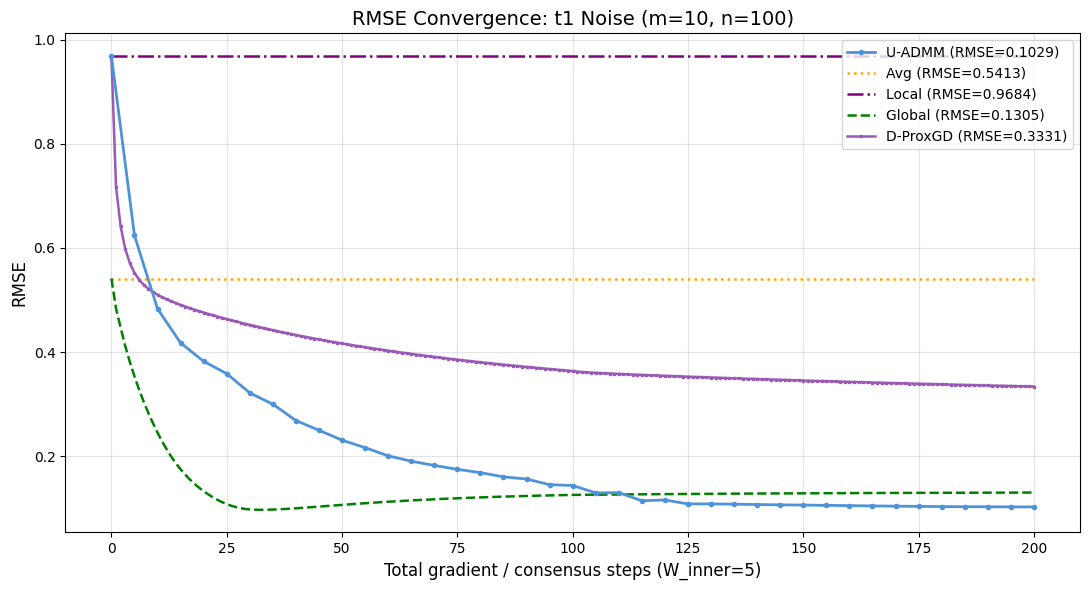

图已保存至 ranking/convergence_comparison.png


In [84]:


# === 3. RMSE 走势对比图 ===
fig, ax = plt.subplots(figsize=(11, 6))

# 1. U-ADMM
ax.plot(x_uadmm, hist_r['rmse'], marker='o', markersize=3, lw=2,
        label=f"U-ADMM (RMSE={hist_r['rmse'][-1]:.4f})", color='#4E93D9', zorder=5)

# 2. Avg
ax.hlines(metrics_avg['RMSE'], xmin=0, xmax=total_steps, color='orange', linestyle=':', lw=1.8,
          label=f"Avg (RMSE={metrics_avg['RMSE']:.4f})")

# 3. Local
if 'rmse_local' in locals() :
    ax.hlines(rmse_local, xmin=0, xmax=total_steps, color='purple', linestyle='-.', lw=1.8,
              label=f"Local (RMSE={rmse_local:.4f})")

# 4. Global
if 'theta_global' in locals() and params.get('run_Global', True):
    if 'hist_global' in locals() and hist_global is not None and 'rmse' in hist_global:
        x_g = np.arange(len(hist_global['rmse']))
        ax.plot(x_g, hist_global['rmse'], color='green', linestyle='--', lw=1.8,
                label=f"Global (RMSE={rmse_global:.4f})")
    else:
        ax.hlines(rmse_global, xmin=0, xmax=total_steps, color='green', linestyle='--', lw=1.8,
                  label=f"Global (RMSE={rmse_global:.4f})")

# 5. D-subGD
if 'theta_dgd' in locals() and params.get('run_DGD', True):
    if 'hist_dgd' in locals() and hist_dgd is not None and 'rmse' in hist_dgd:
        x_d = np.arange(len(hist_dgd['rmse']))
        ax.plot(x_d, hist_dgd['rmse'], color='#EE1C25', linestyle='-.', lw=1.8,
                label=f"D-subGD (RMSE={rmse_dgd:.4f})")
    else:
        ax.hlines(rmse_dgd, xmin=0, xmax=total_steps, color='#EE1C25', linestyle='-.', lw=1.8,
                  label=f"D-subGD (RMSE={rmse_dgd:.4f})")

# 6. D-ProxGD
if 'theta_d_proxgd' in locals() and params.get('run_D_ProxGD', True):
    if 'hist_d_proxgd' in locals() and hist_d_proxgd is not None and 'rmse' in hist_d_proxgd:
        x_d_proxgd = np.arange(len(hist_d_proxgd['rmse']))
        ax.plot(x_d_proxgd, hist_d_proxgd['rmse'], color='#9B59B6', linestyle='-', lw=1.8, marker='s', markersize=2,
                label=f"D-ProxGD (RMSE={rmse_d_proxgd:.4f})")
    else:
        ax.hlines(rmse_d_proxgd, xmin=0, xmax=total_steps, color='#9B59B6', linestyle='-', lw=1.8,
                  label=f"D-ProxGD (RMSE={rmse_d_proxgd:.4f})")

ax.set_xlabel(f'Total gradient / consensus steps (W_inner={W_inner})', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title(f'RMSE Convergence: {noise_type} Noise (m={m}, n={n})', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.35)
plt.tight_layout()

os.makedirs('ranking', exist_ok=True)
plt.savefig('ranking/convergence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'图已保存至 ranking/convergence_comparison.png')

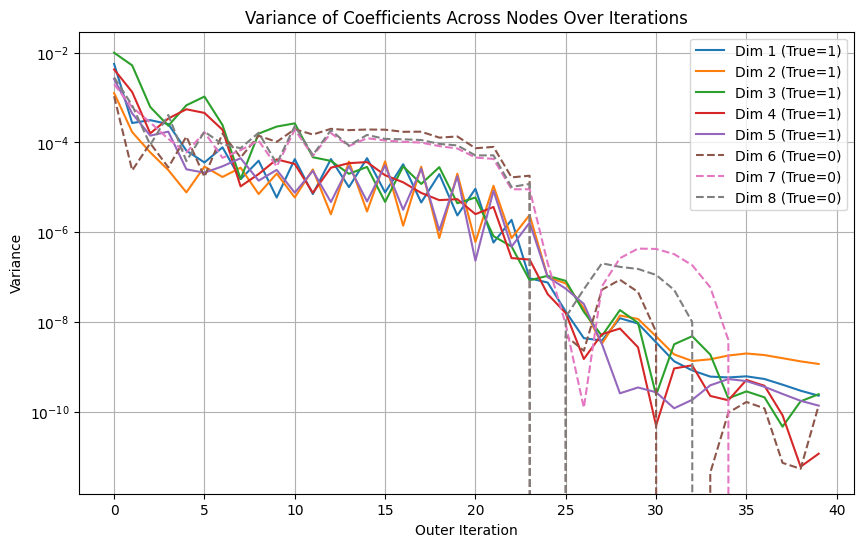

In [85]:
# 绘制系数方差变化图
debug_history = hist_r['debug']
T_iters = len(debug_history)
variances = np.zeros((T_iters, p))

for t in range(T_iters):
    theta_t = debug_history[t]['theta_t']
    theta_mat = np.hstack(theta_t)
    variances[t, :] = np.var(theta_mat, axis=1)

plt.figure(figsize=(10, 6))
for i in range(params['p_prime']):
    plt.plot(range(T_iters), variances[:, i], label=f'Dim {i+1} (True=1)')
for i in range(params['p_prime'], min(params['p_prime']+3, p)):
    plt.plot(range(T_iters), variances[:, i], linestyle='--', label=f'Dim {i+1} (True=0)')

plt.title('Variance of Coefficients Across Nodes Over Iterations')
plt.xlabel('Outer Iteration')
plt.ylabel('Variance')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()


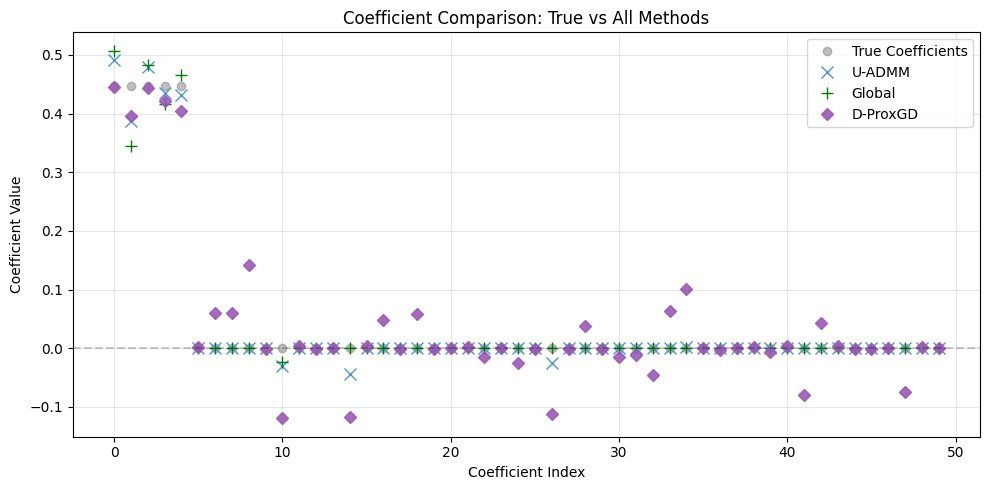

In [86]:

# -- 系数对比图 --
plt.figure(figsize=(10, 5))
# 1. True
plt.plot(theta_true, marker='o', markersize=6, linestyle='None', label='True Coefficients', alpha=0.5, color='gray')
# 2. U-ADMM
plt.plot(theta_uadmm, marker='x', markersize=8, color='#4E93D9', linestyle='None', alpha=1, label='U-ADMM')
# 3. Global
if 'theta_global' in locals() and params.get('run_Global', True):
    plt.plot(theta_global, marker='+', markersize=8, color='green', linestyle='None', label='Global')
# 4. D-subGD
if 'theta_dgd' in locals() and params.get('run_DGD', True):
    plt.plot(theta_dgd, marker='x', markersize=8, color='#EE1C25', linestyle='None', label='D-subGD')
# 5. D-ProxGD
if 'theta_d_proxgd' in locals() and params.get('run_D_ProxGD', True):
    plt.plot(theta_d_proxgd, marker='D', markersize=6, color='#9B59B6', linestyle='None', alpha=0.9, label='D-ProxGD')

plt.axhline(0, color='black', alpha=0.2, linestyle='--')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Comparison: True vs All Methods')
plt.legend(frameon=True, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('ranking', exist_ok=True)
plt.savefig('ranking/coefficient_comparison.png', dpi=150)
plt.show()

In [87]:

# -- 保存结果至 Excel --
import os
import time

result_dict = {
    'Time': time.strftime('%Y-%m-%d %H:%M:%S'),
    'm': m, 'n': params['n'], 'p': p, 'T': T, 'W_inner': W_inner,
    'Noise': params['noise_type'],
    'RMSE_Proposed': calculate_metrics(theta_true, theta_uadmm)['RMSE'],
    'F1_Proposed': calculate_metrics(theta_true, theta_uadmm)['F1_Score'],
    'Kendall_Proposed': evaluate_correlation(d_rank['X'], theta_true, theta_uadmm)['Kendall_Corr'],
}

# 安全添加各基线的 RMSE
if 'rmse_local' in locals():
    result_dict['RMSE_Local'] = rmse_local
if 'rmse_global' in locals():
    result_dict['RMSE_Global'] = rmse_global
if 'rmse_dgd' in locals():
    result_dict['RMSE_DsubGD'] = rmse_dgd
if 'rmse_d_proxgd' in locals():
    result_dict['RMSE_D-ProxGD'] = rmse_d_proxgd

# 记录所有维度的系数对比
for i in range(p):
    result_dict[f'theta_{i}_true'] = float(np.squeeze(theta_true[i]))
    result_dict[f'theta_{i}_uadmm'] = float(np.squeeze(theta_uadmm[i]))
    if 'theta_global' in locals():
        result_dict[f'theta_{i}_global'] = float(np.squeeze(theta_global[i]))
    if 'theta_dgd' in locals():
        result_dict[f'theta_{i}_dgd'] = float(np.squeeze(theta_dgd[i]))
    if 'theta_d_proxgd' in locals():
        result_dict[f'theta_{i}_d_proxgd'] = float(np.squeeze(theta_d_proxgd[i]))

excel_path = 'ranking/results.xlsx'
os.makedirs('ranking', exist_ok=True)
append_to_excel(excel_path, result_dict)
print(f'实验结果已保存至 {excel_path}')

实验结果已保存至 ranking/results.xlsx
